# TravelMind — essai 700 premières lignes — Version rattrapage

Cette version recentre le projet sur une lecture plus claire et plus convergente suite aux retours jury.

Objectif initial : prédire avant le départ un **score de satisfaction client de 1 à 5** à partir des seules informations disponibles en pré-voyage.

Essai ajouté : `imprevus`, `reorganisation_necessaire` et `respect_budget` sont réintroduites comme variables d'entrée pour mesurer leur impact. Cet essai n'est pas compatible avec un usage pré-voyage strict, car ces informations sont connues pendant ou après le séjour.

Message central : le pipeline est industrialisable, mais les données pré-voyage actuelles contiennent peu de signal. Les variables post-voyage peuvent augmenter le signal, mais elles doivent être utilisées uniquement pour une analyse post-voyage ou une amélioration continue, pas pour une prédiction avant départ.

> Notebook expérimental : même démarche que la version rattrapage, mais limitée aux 700 premières lignes du dataset original pour comparer l'impact de la volumétrie et de l'enrichissement.


## 1. Cadrage synthétique

### Problème métier

Une agence de voyages haut de gamme souhaite identifier avant le départ les séjours susceptibles de générer une satisfaction faible ou moyenne, afin de renforcer l'accompagnement humain.

### Plus-value attendue

- Donner au conseiller un score indicatif de satisfaction probable.
- Prioriser les dossiers nécessitant une revue humaine.
- Structurer un pipeline reproductible pour préparer une future amélioration avec données réelles.

### Limite assumée

La prédiction ne remplace pas le conseiller. Avec les données actuelles, elle sert principalement de prototype analytique et industrialisable.


## 2. Imports et configuration


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.modeling import (
    RANDOM_STATE,
    TARGET_COLUMN,
    add_base_features,
    clean_dataset,
    prepare_training_dataset,
    build_preprocessor,
    candidate_models,
    clip_satisfaction_score,
    train_and_select_model,
)

DATA_PATH = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "model_pre_voyage.pkl"
METADATA_PATH = PROJECT_ROOT / "models" / "model_pre_voyage_metadata.json"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
sns.set_theme(style="whitegrid")


## 3. Chargement du dataset

Le dataset utilisé est synthétique, anonymisé et fourni dans le cadre du projet. Il contient des séjours passés avec leurs caractéristiques, contraintes, résultats opérationnels et satisfaction client.


In [2]:
# Essai volontaire : on charge le dataset original puis on garde uniquement les 700 premières lignes.
# Le fichier source reste inchangé.
df_raw_complet = pd.read_csv(DATA_PATH)
df_raw = df_raw_complet.head(700).copy()
print(f"Nombre de lignes : {df_raw.shape[0]}")
print(f"Nombre de colonnes : {df_raw.shape[1]}")
display(df_raw.head())


Nombre de lignes : 700
Nombre de colonnes : 15


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


In [3]:
datasheet_variables = pd.DataFrame([
    {"variable": "trip_id", "role": "identifiant", "usage": "Exclu du modèle"},
    {"variable": "client_type", "role": "profil client", "usage": "Entrée pré-voyage"},
    {"variable": "budget_total", "role": "budget global", "usage": "Entrée pré-voyage"},
    {"variable": "destination", "role": "destination", "usage": "Entrée pré-voyage"},
    {"variable": "saison", "role": "période", "usage": "Entrée pré-voyage"},
    {"variable": "duree_jours", "role": "durée", "usage": "Entrée pré-voyage"},
    {"variable": "type_hebergement", "role": "hébergement", "usage": "Entrée pré-voyage"},
    {"variable": "prix_vol", "role": "coùt transport", "usage": "Entrée pré-voyage"},
    {"variable": "meteo_prevue", "role": "contexte météo", "usage": "Entrée pré-voyage"},
    {"variable": "activite_principale", "role": "centre d'intérêt", "usage": "Entrée pré-voyage"},
    {"variable": "satisfaction_client", "role": "cible", "usage": "Score à prédire"},
    {"variable": "imprevus", "role": "événement post-voyage", "usage": "Entrée expérimentale, non pré-voyage strict"},
    {"variable": "reorganisation_necessaire", "role": "résultat opérationnel", "usage": "Entrée expérimentale, non pré-voyage strict"},
    {"variable": "respect_budget", "role": "résultat budgétaire", "usage": "Entrée expérimentale, non pré-voyage strict"},
    {"variable": "retour_client", "role": "avis post-voyage", "usage": "Exclu du modèle pré-voyage"},
])
display(datasheet_variables)


,variable,role,usage
0,trip_id,identifiant,Exclu du modèle
1,client_type,profil client,Entrée pré-voyage
2,budget_total,budget global,Entrée pré-voyage
3,destination,destination,Entrée pré-voyage
4,saison,période,Entrée pré-voyage
5,duree_jours,durée,Entrée pré-voyage
6,type_hebergement,hébergement,Entrée pré-voyage
7,prix_vol,coùt transport,Entrée pré-voyage
8,meteo_prevue,contexte météo,Entrée pré-voyage
9,activite_principale,centre d'intérêt,Entrée pré-voyage


## 4. Préparation des données - synthèse C3

### 4.1 Finalité

La préparation des données vise un objectif précis : construire un dataset **cohérent, traçable et exploitable pour un modèle pré-voyage**.

La plus-value n'est pas de multiplier les traitements, mais de sécuriser les données utilisées par le modèle :

- conserver uniquement les informations disponibles avant le départ ;
- supprimer les cas impossibles ou contradictoires pour éviter un apprentissage incohérent ;
- centraliser les règles métier dans `configs/business_rules.json` ;
- laisser les traitements apprenants dans le pipeline `scikit-learn` après le split train/test.

### 4.2 Principe de décision

Seules les incohérences critiques sont supprimées. Les cas discutables mais métier possibles sont conservés et documentés, afin de ne pas appauvrir artificiellement le dataset.


In [4]:
from app.config import load_business_rules

# Lecture des règles métier centralisées.
# Elles évitent de modifier le notebook à chaque évolution de borne, catégorie ou seuil.
business_rules = load_business_rules()

contraintes_numeriques = pd.DataFrame([
    {
        "variable": variable,
        "minimum": limites.get("min"),
        "maximum": limites.get("max"),
        "objectif": {
            "duree_jours": "écarter les durées irréalistes",
            "budget_total": "écarter les budgets hors périmètre métier",
            "prix_vol": "écarter les coûts de vol hors périmètre métier",
        }.get(variable, "contrôle métier"),
    }
    for variable, limites in business_rules["api_constraints"].items()
])

categories_fermees = pd.DataFrame([
    {
        "variable": variable,
        "valeurs_autorisees": ", ".join(valeurs),
        "objectif": "éviter les catégories inconnues sur les champs métier fermés",
    }
    for variable, valeurs in business_rules["allowed_categories"].items()
])

display(contraintes_numeriques)
display(categories_fermees)


,variable,minimum,maximum,objectif
0,duree_jours,1,90,écarter les durées irréalistes
1,budget_total,500,50000,écarter les budgets hors périmètre métier
2,prix_vol,0,15000,écarter les coûts de vol hors périmètre métier


,variable,valeurs_autorisees,objectif
0,client_type,"famille, couple, solo, business, senior",éviter les catégories inconnues sur les champs...
1,saison,"hiver, printemps, été, automne",éviter les catégories inconnues sur les champs...
2,type_hebergement,"hôtel, resort, appartement, villa",éviter les catégories inconnues sur les champs...
3,meteo_prevue,"ensoleillé, nuageux, pluie, variable",éviter les catégories inconnues sur les champs...
4,activite_principale,"plage, randonnée, gastronomie, culture, business",éviter les catégories inconnues sur les champs...


In [5]:
# Contrôles d'intégrité initiaux.
# Ces contrôles servent à distinguer les anomalies critiques des simples cas métier atypiques.
imprevus_norm = (
    df_raw["imprevus"]
    .fillna("aucun")
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({"": "aucun", "nan": "aucun"})
)

def compter_hors_bornes(variable):
    limites = business_rules["api_constraints"][variable]
    valeurs = pd.to_numeric(df_raw[variable], errors="coerce")
    masque = pd.Series(False, index=df_raw.index)
    if limites.get("min") is not None:
        masque |= valeurs < limites["min"]
    if limites.get("max") is not None:
        masque |= valeurs > limites["max"]
    return masque

masque_hors_bornes = pd.Series(False, index=df_raw.index)
for variable in business_rules["api_constraints"]:
    masque_hors_bornes |= compter_hors_bornes(variable)

controle_qualite_initial = pd.DataFrame([
    {
        "controle": "doublons trip_id",
        "nb_lignes": int(df_raw["trip_id"].duplicated().sum()),
        "decision": "supprimer si présent",
        "plus_value": "éviter le double comptage d'un séjour",
    },
    {
        "controle": "satisfaction absente ou hors échelle 1-5",
        "nb_lignes": int((df_raw[TARGET_COLUMN].isna() | ~df_raw[TARGET_COLUMN].between(1, 5)).sum()),
        "decision": "supprimer",
        "plus_value": "garantir une cible d'apprentissage valide",
    },
    {
        "controle": "valeurs hors bornes métier configurées",
        "nb_lignes": int(masque_hors_bornes.sum()),
        "decision": "supprimer",
        "plus_value": "écarter les séjours hors périmètre du cas d'usage",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": int((df_raw["prix_vol"] > df_raw["budget_total"]).sum()),
        "decision": "supprimer",
        "plus_value": "éviter une incohérence budgétaire forte",
    },
    {
        "controle": "aucun imprévu mais réorganisation nécessaire",
        "nb_lignes": int(((imprevus_norm == "aucun") & (df_raw["reorganisation_necessaire"] == 1)).sum()),
        "decision": "supprimer",
        "plus_value": "éviter une contradiction opérationnelle forte",
    },
])

display(controle_qualite_initial)

# Application du nettoyage stabilisé utilisé aussi par train.py.
df_clean, cleaning_report = clean_dataset(df_raw)
df_model = add_base_features(df_clean)

finalites_preparation = {
    "dataset_brut": "point de départ fourni",
    "cible_satisfaction_client_valide": "cible exploitable pour la régression",
    "contraintes_metier_config": "périmètre métier cohérent avec l'API",
    "coherence_initiale_prix_vol_budget_total": "budget total compatible avec le coût du vol",
    "reorganisation_sans_imprevu_declare": "cohérence opérationnelle minimale",
}

rapport_nettoyage = pd.DataFrame(cleaning_report)
rapport_nettoyage["lignes_supprimees_cumulees"] = len(df_raw) - rapport_nettoyage["nb_lignes"]
rapport_nettoyage["lignes_restantes_pct"] = (rapport_nettoyage["nb_lignes"] / len(df_raw) * 100).round(2)
rapport_nettoyage["finalite"] = rapport_nettoyage["etape"].map(finalites_preparation)

display(rapport_nettoyage)

print(f"Lignes initiales : {len(df_raw)}")
print(f"Lignes après nettoyage : {len(df_clean)}")
print(f"Lignes supprimées : {len(df_raw) - len(df_clean)}")


,controle,nb_lignes,decision,plus_value
0,doublons trip_id,0,supprimer si présent,éviter le double comptage d'un séjour
1,satisfaction absente ou hors échelle 1-5,0,supprimer,garantir une cible d'apprentissage valide
2,valeurs hors bornes métier configurées,0,supprimer,écarter les séjours hors périmètre du cas d'usage
3,prix_vol > budget_total,5,supprimer,éviter une incohérence budgétaire forte
4,aucun imprévu mais réorganisation nécessaire,18,supprimer,éviter une contradiction opérationnelle forte


,etape,nb_lignes,lignes_supprimees,lignes_supprimees_cumulees,lignes_restantes_pct,finalite
0,dataset_brut,700,0,0,100.00,point de départ fourni
1,unicite_trip_id,700,0,0,100.00,NaN
2,cible_satisfaction_client_valide,700,0,0,100.00,cible exploitable pour la régression
3,contraintes_metier_config,700,0,0,100.00,périmètre métier cohérent avec l'API
4,coherence_initiale_prix_vol_budget_total,695,5,5,99.29,budget total compatible avec le coût du vol
5,reorganisation_sans_imprevu_declare,677,18,23,96.71,cohérence opérationnelle minimale


Lignes initiales : 700
Lignes après nettoyage : 677
Lignes supprimées : 23


### 4.3 Traitements placés dans le pipeline

Les traitements qui apprennent des paramètres ne sont pas appliqués directement sur tout le dataset avant la séparation train/test.

Ils sont intégrés au pipeline `scikit-learn` :

- imputation des valeurs manquantes ;
- traitement IQR des valeurs aberrantes numériques ;
- standardisation des variables numériques continues ;
- encodage `OneHotEncoder` des variables catégorielles.

Cette organisation limite le risque de fuite de données entre le train et le test.

### 4.4 Conclusion C3 - plus-value de la préparation

La préparation réduit le dataset de `1500` à `1378` lignes, uniquement après suppression de cas invalides, hors périmètre ou fortement incohérents. Le dataset final est plus fiable, mieux aligné avec l'usage pré-voyage et réutilisable par le notebook, `train.py`, l'API et le monitoring.

La section C3 est donc recentrée sur la finalité : **produire une base propre et défendable**, sans prétendre améliorer artificiellement la performance du modèle.


## 5. Feature engineering retenu

Les nouvelles variables sont limitées à des informations disponibles avant le départ.


In [6]:
x_pre, y_pre, cleaning_report = prepare_training_dataset(df_raw)

# Essai expérimental : ajout de trois variables post-voyage dans les entrées.
# Attention : ces variables ne seraient pas disponibles pour une vraie prédiction avant départ.
df_clean_inputs, _ = clean_dataset(df_raw)
df_model_inputs = add_base_features(df_clean_inputs)

variables_post_voyage_entrees = ["imprevus", "reorganisation_necessaire", "respect_budget"]
for variable in variables_post_voyage_entrees:
    x_pre[variable] = df_model_inputs.loc[x_pre.index, variable]

features_resume = pd.DataFrame([
    {"feature": "budget_par_jour", "definition": "budget_total / duree_jours", "raison": "Comparer les séjours de durées différentes"},
    {"feature": "part_vol_budget", "definition": "prix_vol / budget_total", "raison": "Mesurer le poids du transport dans le budget"},
    {"feature": "sejour_long", "definition": "1 si duree_jours >= 14", "raison": "Identifier les séjours longs"},
    {"feature": "meteo_risque", "definition": "1 si pluie ou variable", "raison": "Repérer un contexte météo moins favorable"},
    {"feature": "client_business", "definition": "1 si client_type = business", "raison": "Isoler les voyages professionnels"},
    {"feature": "hebergement_luxe", "definition": "1 si resort ou villa", "raison": "Identifier un niveau d'hébergement premium"},
    {"feature": "imprevus", "definition": "type d'imprévu observé", "raison": "Variable post-voyage ajoutée uniquement pour mesurer le signal explicatif"},
    {"feature": "reorganisation_necessaire", "definition": "1 si le séjour a nécessité une réorganisation", "raison": "Variable post-voyage ajoutée uniquement pour mesurer le signal explicatif"},
    {"feature": "respect_budget", "definition": "1 si le budget a été respecté", "raison": "Variable post-voyage ajoutée uniquement pour mesurer le signal explicatif"},
])

display(features_resume)
print(f"Nombre total de variables d'entrée : {x_pre.shape[1]}")
display(pd.DataFrame({"features_modelisation": x_pre.columns}))


,feature,definition,raison
0,budget_par_jour,budget_total / duree_jours,Comparer les séjours de durées différentes
1,part_vol_budget,prix_vol / budget_total,Mesurer le poids du transport dans le budget
2,sejour_long,1 si duree_jours >= 14,Identifier les séjours longs
3,meteo_risque,1 si pluie ou variable,Repérer un contexte météo moins favorable
4,client_business,1 si client_type = business,Isoler les voyages professionnels
5,hebergement_luxe,1 si resort ou villa,Identifier un niveau d'hébergement premium
6,imprevus,type d'imprévu observé,Variable post-voyage ajoutée uniquement pour m...
7,reorganisation_necessaire,1 si le séjour a nécessité une réorganisation,Variable post-voyage ajoutée uniquement pour m...
8,respect_budget,1 si le budget a été respecté,Variable post-voyage ajoutée uniquement pour m...


Nombre total de variables d'entrée : 18


,features_modelisation
0,client_type
1,budget_total
2,destination
3,saison
4,duree_jours
5,type_hebergement
6,prix_vol
7,meteo_prevue
8,activite_principale
9,budget_par_jour


### 5.1 Enrichissement expérimental pré-voyage - 700 lignes

Faute de fichiers sources réels, cette section simule un enrichissement externe comme s'il provenait de référentiels métier disponibles avant le départ : qualité d'hébergement, durée de vol, nombre d'escales, distance, coùt de vie destination, météo saisonnière et attractivité de l'activité.

Cette expérience sert uniquement à mesurer l'effet potentiel d'un enrichissement. Elle ne doit pas être présentée comme une preuve issue de données externes réelles tant que les sources ne sont pas vérifiées et documentées.


In [7]:
x_pre_non_enrichi = x_pre.copy()

# Enrichissement expérimental : valeurs de référence simulées, disponibles avant voyage.
# Objectif : tester l'effet potentiel de variables métier plus explicatives.
def canoniser_destination(valeur):
    texte = str(valeur).strip().lower()
    if "new york" in texte:
        return "new_york"
    if "lisbonne" in texte:
        return "lisbonne"
    if "duba" in texte:
        return "dubai"
    if "sydney" in texte:
        return "sydney"
    if "tokyo" in texte:
        return "tokyo"
    if "bali" in texte:
        return "bali"
    if "rome" in texte:
        return "rome"
    if "paris" in texte:
        return "paris"
    return "autre"


def canoniser_hebergement(valeur):
    texte = str(valeur).strip().lower()
    if "resort" in texte:
        return "resort"
    if "villa" in texte:
        return "villa"
    if "appartement" in texte:
        return "appartement"
    if "tel" in texte:
        return "hotel"
    return "autre"


def canoniser_saison(valeur):
    texte = str(valeur).strip().lower()
    if "hiver" in texte:
        return "hiver"
    if "printemps" in texte:
        return "printemps"
    if "automne" in texte:
        return "automne"
    return "ete"


def canoniser_activite(valeur):
    texte = str(valeur).strip().lower()
    if "plage" in texte:
        return "plage"
    if "randon" in texte:
        return "randonnee"
    if "gastronomie" in texte:
        return "gastronomie"
    if "culture" in texte:
        return "culture"
    if "business" in texte:
        return "business"
    return "autre"


x_pre_enrichi = x_pre.copy()
destination_key = x_pre_enrichi["destination"].map(canoniser_destination)
hebergement_key = x_pre_enrichi["type_hebergement"].map(canoniser_hebergement)
saison_key = x_pre_enrichi["saison"].map(canoniser_saison)
activite_key = x_pre_enrichi["activite_principale"].map(canoniser_activite)

duree_vol = {
    "paris": 1.2,
    "rome": 2.0,
    "lisbonne": 2.5,
    "dubai": 6.8,
    "new_york": 8.2,
    "bali": 17.0,
    "sydney": 22.0,
    "tokyo": 14.0,
}

distance_vol = {
    "paris": 350,
    "rome": 1100,
    "lisbonne": 1450,
    "dubai": 5250,
    "new_york": 5850,
    "bali": 12400,
    "sydney": 16900,
    "tokyo": 9700,
}

note_destination = {
    "paris": 4.5,
    "rome": 4.4,
    "lisbonne": 4.3,
    "dubai": 4.2,
    "new_york": 4.1,
    "bali": 4.6,
    "sydney": 4.3,
    "tokyo": 4.4,
}

cout_vie_destination = {
    "paris": 1.25,
    "rome": 1.05,
    "lisbonne": 0.90,
    "dubai": 1.40,
    "new_york": 1.55,
    "bali": 0.80,
    "sydney": 1.50,
    "tokyo": 1.35,
}

note_hebergement = {
    "hotel": 4.2,
    "resort": 4.5,
    "appartement": 3.9,
    "villa": 4.6,
}

classement_hebergement = {
    "hotel": 4,
    "resort": 5,
    "appartement": 3,
    "villa": 5,
}

risque_pluie_saisonnier = {
    "hiver": 0.65,
    "printemps": 0.25,
    "ete": 0.15,
    "automne": 0.40,
}

score_activite_destination = {
    "plage": 4.4,
    "randonnee": 4.2,
    "gastronomie": 4.3,
    "culture": 4.2,
    "business": 3.6,
}

x_pre_enrichi["duree_vol_heures"] = destination_key.map(duree_vol).astype(float)
x_pre_enrichi["distance_vol_km"] = destination_key.map(distance_vol).astype(float)
x_pre_enrichi["nb_escales_moyen"] = np.select(
    [x_pre_enrichi["duree_vol_heures"] > 12, x_pre_enrichi["duree_vol_heures"] > 6],
    [1.5, 0.7],
    default=0.1,
)
x_pre_enrichi["note_destination"] = destination_key.map(note_destination).astype(float)
x_pre_enrichi["cout_vie_destination"] = destination_key.map(cout_vie_destination).astype(float)
x_pre_enrichi["note_hebergement"] = hebergement_key.map(note_hebergement).astype(float)
x_pre_enrichi["classement_hebergement"] = hebergement_key.map(classement_hebergement).astype(float)
x_pre_enrichi["risque_pluie_saisonnier"] = saison_key.map(risque_pluie_saisonnier).astype(float)
x_pre_enrichi["score_activite_destination"] = activite_key.map(score_activite_destination).astype(float)
x_pre_enrichi["complexite_transport"] = (
    x_pre_enrichi["duree_vol_heures"].fillna(0)
    + 2 * x_pre_enrichi["nb_escales_moyen"].fillna(0)
)
x_pre_enrichi["budget_ajuste_cout_vie"] = (
    x_pre_enrichi["budget_par_jour"] / x_pre_enrichi["cout_vie_destination"]
)
x_pre_enrichi["adequation_budget_luxe"] = (
    x_pre_enrichi["budget_ajuste_cout_vie"] * x_pre_enrichi["note_hebergement"]
)
x_pre_enrichi["risque_meteo_activite_exterieure"] = (
    (x_pre_enrichi["meteo_risque"] == 1)
    & activite_key.isin(["plage", "randonnee"])
).astype(int)

features_enrichissement = [
    colonne for colonne in x_pre_enrichi.columns
    if colonne not in x_pre_non_enrichi.columns
]

resume_enrichissement = pd.DataFrame([
    {"source_simulee": "vols", "features": "duree_vol_heures, distance_vol_km, nb_escales_moyen, complexite_transport"},
    {"source_simulee": "hebergement", "features": "note_hebergement, classement_hebergement"},
    {"source_simulee": "destination", "features": "note_destination, cout_vie_destination"},
    {"source_simulee": "meteo", "features": "risque_pluie_saisonnier, risque_meteo_activite_exterieure"},
    {"source_simulee": "budget", "features": "budget_ajuste_cout_vie, adequation_budget_luxe"},
    {"source_simulee": "activite", "features": "score_activite_destination"},
])

display(resume_enrichissement)
print(f"Variables avant enrichissement : {x_pre_non_enrichi.shape[1]}")
print(f"Variables après enrichissement : {x_pre_enrichi.shape[1]}")
display(pd.DataFrame({"features_ajoutees": features_enrichissement}))
display(x_pre_enrichi[features_enrichissement].head())

# à partir de cette cellule, toute la démarche utilise le dataset enrichi.
x_pre = x_pre_enrichi.copy()


,source_simulee,features
0,vols,"duree_vol_heures, distance_vol_km, nb_escales_..."
1,hebergement,"note_hebergement, classement_hebergement"
2,destination,"note_destination, cout_vie_destination"
3,meteo,"risque_pluie_saisonnier, risque_meteo_activite..."
4,budget,"budget_ajuste_cout_vie, adequation_budget_luxe"
5,activite,score_activite_destination


Variables avant enrichissement : 18
Variables après enrichissement : 31


,features_ajoutees
0,duree_vol_heures
1,distance_vol_km
2,nb_escales_moyen
3,note_destination
4,cout_vie_destination
5,note_hebergement
6,classement_hebergement
7,risque_pluie_saisonnier
8,score_activite_destination
9,complexite_transport


,duree_vol_heures,distance_vol_km,nb_escales_moyen,note_destination,cout_vie_destination,note_hebergement,classement_hebergement,risque_pluie_saisonnier,score_activite_destination,complexite_transport,budget_ajuste_cout_vie,adequation_budget_luxe,risque_meteo_activite_exterieure
0,6.8,5250.0,0.7,4.2,1.40,4.2,4.0,0.40,4.4,8.2,1321.166667,5548.900000,0
1,2.0,1100.0,0.1,4.4,1.05,4.2,4.0,0.25,4.2,2.2,260.973810,1096.090000,1
2,17.0,12400.0,1.5,4.6,0.80,4.6,5.0,0.25,4.4,20.0,1042.748437,4796.642812,0
3,22.0,16900.0,1.5,4.3,1.50,3.9,3.0,0.40,4.2,25.0,276.447843,1078.146588,0
4,1.2,350.0,0.1,4.5,1.25,4.2,4.0,0.65,4.3,1.4,870.048000,3654.201600,0


#### Lecture de l'enrichissement expérimental

Avant enrichissement externe simulé, l'essai contient `18` variables d'entrée : les variables pré-voyage, les features de base et les trois variables post-voyage testées.

L'enrichissement ajoute ensuite `13` variables supplémentaires. Elles donnent plus de sens métier aux données : complexité du transport, qualité de l'hébergement, attractivité de la destination, risque météo et budget ajusté au coût de vie.

Cette étape permet de tester si la faiblesse du modèle vient seulement du choix d'algorithme ou plutôt du manque d'informations explicatives dans le dataset initial.


## 6. Variables exclues et variables post-voyage testées

Dans ce notebook expérimental, `imprevus`, `reorganisation_necessaire` et `respect_budget` sont volontairement ajoutées en entrée pour mesurer leur impact sur la prédiction de la satisfaction.

Cette variante ne doit pas être confondue avec un modèle pré-voyage strict : ces trois variables sont connues pendant ou après le séjour. Leur usage est donc cohérent pour une analyse post-voyage, une analyse de causes ou une amélioration continue, mais pas pour anticiper la satisfaction avant le départ.


In [8]:
variables_incluses_experimentales = pd.DataFrame([
    {"variable": "imprevus", "raison": "Tester l'impact des événements observés pendant/après le séjour"},
    {"variable": "reorganisation_necessaire", "raison": "Tester l'impact d'une réorganisation opérationnelle sur la satisfaction"},
    {"variable": "respect_budget", "raison": "Tester l'impact du respect du budget sur la satisfaction"},
])

variables_exclues = pd.DataFrame([
    {"variable": "retour_client", "raison": "Avis client post-voyage, trop proche de la cible"},
    {"variable": "trip_id", "raison": "Identifiant sans valeur prédictive métier"},
])

print("Variables post-voyage ajoutées à titre expérimental :")
display(variables_incluses_experimentales)
print("Variables encore exclues :")
display(variables_exclues)


Variables post-voyage ajoutées à titre expérimental :


,variable,raison
0,imprevus,Tester l'impact des événements observés pendan...
1,reorganisation_necessaire,Tester l'impact d'une réorganisation opération...
2,respect_budget,Tester l'impact du respect du budget sur la sa...


Variables encore exclues :


,variable,raison
0,retour_client,"Avis client post-voyage, trop proche de la cible"
1,trip_id,Identifiant sans valeur prédictive métier


## 7. Choix du modèle IA - synthèse C4

### 7.1 Logique de convergence

Suite aux retours jury, le choix du modèle est présenté comme un **entonnoir de décision** : on part du besoin métier, on teste quelques familles représentatives, puis on retient le meilleur compromis.

### Besoin métier traité

Le besoin retenu pour la version rattrapage est de prédire **avant le départ** un score indicatif de satisfaction client sur l'échelle `1 à 5`.

Ce choix conduit à un problème de **régression supervisée** :

- entrée : variables connues avant le voyage ;
- sortie : score continu de satisfaction ;
- métriques principales : `MAE`, `RMSE`, `R2` ;
- métriques non prioritaires : rappel, matrice de confusion et ROC, car elles concernent surtout la classification.

### Critères de choix

Le modèle retenu doit être :

- adapté au cas d'usage pré-voyage ;
- comparable à une baseline naïve ;
- stable avec les variables catégorielles encodées ;
- explicable devant le métier ;
- sobre en calcul ;
- facilement industrialisable dans l'API, Docker et la CI/CD ;
- sans fuite de données post-voyage.


In [9]:
# Entraînement et comparaison de modèles candidats.
# La sélection se fait sur la MAE : plus elle est basse, plus l'erreur moyenne est faible.
training_result = train_and_select_model(
    x=x_pre,
    y=y_pre,
    cleaning_report=cleaning_report,
    test_size=0.2,
)

resultats_modeles = pd.DataFrame(training_result.evaluation_results)
baseline_mae = resultats_modeles.loc[
    resultats_modeles["modele"] == "Dummy_mean_regression",
    "mae",
].iloc[0]
resultats_modeles["gain_mae_vs_baseline"] = baseline_mae - resultats_modeles["mae"]

criteres_modeles = pd.DataFrame([
    {
        "modele": "Dummy_mean_regression",
        "famille": "baseline naïve",
        "role": "point de comparaison minimal",
        "decision": "non retenu : ne modélise aucune relation",
    },
    {
        "modele": "LinearRegression_pre",
        "famille": "régression linéaire simple",
        "role": "modèle interprétable de référence",
        "decision": "non retenu : moins stable avec l'encodage catégoriel",
    },
    {
        "modele": "RidgeRegression_pre",
        "famille": "régression linéaire régularisée",
        "role": "compromis performance, stabilité et explicabilité",
        "decision": "meilleur candidat de base sur cet essai enrichi, mais gain trop faible",
    },
    {
        "modele": "RandomForestRegressor_pre",
        "famille": "ensemble non linéaire",
        "role": "tester si des relations non linéaires améliorent le score",
        "decision": "non retenu : complexité supérieure sans gain suffisant",
    },
])

synthese_choix = (
    resultats_modeles
    .merge(criteres_modeles, on="modele", how="left")
    .sort_values(["mae", "rmse"], ascending=[True, True])
    .reset_index(drop=True)
)

colonnes_synthese = [
    "modele",
    "famille",
    "mae",
    "rmse",
    "r2",
    "gain_mae_vs_baseline",
    "role",
    "decision",
]

display(synthese_choix[colonnes_synthese].round(4))

print(f"Modèle retenu : {training_result.model_name}")
print(json.dumps(training_result.metrics, indent=2, ensure_ascii=False))


,modele,famille,mae,rmse,r2,gain_mae_vs_baseline,role,decision
0,RidgeRegression_pre,régression linéaire régularisée,0.8213,1.0116,0.1044,0.0787,"compromis performance, stabilité et explicabilité",meilleur candidat de base sur cet essai enrich...
1,LinearRegression_pre,régression linéaire simple,0.8218,1.0121,0.1036,0.0783,modèle interprétable de référence,non retenu : moins stable avec l'encodage caté...
2,RandomForestRegressor_pre,ensemble non linéaire,0.8474,0.9980,0.1284,0.0527,tester si des relations non linéaires améliore...,non retenu : complexité supérieure sans gain s...
3,Dummy_mean_regression,baseline naïve,0.9000,1.0690,-0.0000,0.0000,point de comparaison minimal,non retenu : ne modélise aucune relation


Modèle retenu : RidgeRegression_pre
{
  "mae": 0.8213023062006046,
  "rmse": 1.011648611579677,
  "r2": 0.10435698298547957,
  "baseline_mae": 0.9000353376100902,
  "mae_gain_vs_baseline": 0.07873303140948562,
  "test_size": 0.2,
  "train_rows": 541,
  "test_rows": 136
}


### 7.2 Lecture des métriques et décision

- `MAE` : erreur moyenne absolue en points de satisfaction. Une MAE autour de `0.82` signifie que le modèle se trompe en moyenne d'environ `0.82` point sur l'échelle `1 à 5`.
- `RMSE` : mesure proche de la MAE, mais plus sensible aux grosses erreurs.
- `R2` : part de variance expliquée par le modèle. Ici, `R2 = 0.1044` pour `RidgeRegression_pre`, donc le modèle explique environ `10 %` de la variance observée.
- `gain_mae_vs_baseline` : écart entre le modèle testé et la baseline `Dummy_mean_regression`.

### Lecture chiffrée avec variables post-voyage et enrichissement simulé

- `RidgeRegression_pre` obtient `MAE = 0.8213`, contre `0.9000` pour la baseline.
- Le gain par rapport à la baseline est de `+0.0787` point de MAE.
- `RandomForestRegressor_pre` obtient `MAE = 0.8474`, donc il reste moins performant que `RidgeRegression_pre` en MAE, mais son `R2 = 0.1284` est meilleur.
- L'amélioration vient probablement surtout de `imprevus`, `reorganisation_necessaire` et `respect_budget`, qui apportent du signal post-voyage.

### 7.3 Décision C4

Dans cet essai sur `700` lignes, `RidgeRegression_pre` reste le meilleur candidat de base selon la MAE. Le score s'améliore, mais l'usage change : le modèle n'est plus un vrai modèle pré-voyage strict, car il utilise des informations connues pendant ou après le séjour. Cette variante est donc utile pour l'analyse de causes, pas pour l'industrialisation pré-voyage.


### 7.4 Essai Gradient Boosting - 700 lignes

Cet essai remplace l'optimisation Random Forest. L'objectif est de tester deux modèles de boosting capables de corriger progressivement les erreurs :

- `GradientBoostingRegressor` : boosting classique sur arbres ;
- `HistGradientBoostingRegressor` : version histogramme, souvent plus rapide sur gros volumes.

Les traitements restent dans le pipeline : imputation, traitement IQR, standardisation et encodage.

In [10]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline

modeles_boosting_700 = {
    "GradientBoostingRegressor_pre": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "HistGradientBoostingRegressor_pre": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        max_iter=200,
    ),
}

cv_700 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
preprocess_cv_700, _, _ = build_preprocessor(x_pre)

resultats_cv_boosting_700 = []

for model_name, model in modeles_boosting_700.items():
    pipeline_cv = Pipeline(steps=[
        ("preprocess", clone(preprocess_cv_700)),
        ("model", model),
    ])

    scores = cross_validate(
        pipeline_cv,
        x_pre,
        y_pre,
        cv=cv_700,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
    )

    resultats_cv_boosting_700.append({
        "modele": model_name,
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_r2_mean": scores["test_r2"].mean(),
    })

resultats_cv_boosting_700 = (
    pd.DataFrame(resultats_cv_boosting_700)
    .sort_values(["cv_mae_mean", "cv_rmse_mean"])
    .reset_index(drop=True)
)

display(resultats_cv_boosting_700.round(4))

,modele,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean
0,GradientBoostingRegressor_pre,0.8280,0.0424,1.0120,0.1136
1,HistGradientBoostingRegressor_pre,0.8791,0.0395,1.0881,-0.0241


In [11]:
X_train_boost_700, X_test_boost_700, y_train_boost_700, y_test_boost_700 = train_test_split(
    x_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre.astype(int),
)

preprocess_boost_700, _, _ = build_preprocessor(X_train_boost_700)

mae_baseline_700 = resultats_modeles.loc[
    resultats_modeles["modele"] == "Dummy_mean_regression",
    "mae",
].iloc[0]

mae_rf_initial_700 = resultats_modeles.loc[
    resultats_modeles["modele"] == "RandomForestRegressor_pre",
    "mae",
].iloc[0]

resultats_test_boosting_700 = []

for model_name, model in modeles_boosting_700.items():
    pipeline_boost = Pipeline(steps=[
        ("preprocess", clone(preprocess_boost_700)),
        ("model", model),
    ])

    pipeline_boost.fit(X_train_boost_700, y_train_boost_700)
    predictions = clip_satisfaction_score(pipeline_boost.predict(X_test_boost_700))
    mae = mean_absolute_error(y_test_boost_700, predictions)

    resultats_test_boosting_700.append({
        "modele": model_name,
        "mae": mae,
        "rmse": np.sqrt(mean_squared_error(y_test_boost_700, predictions)),
        "r2": r2_score(y_test_boost_700, predictions),
        "gain_mae_vs_baseline": mae_baseline_700 - mae,
        "gain_mae_vs_rf_initial": mae_rf_initial_700 - mae,
    })

resultats_test_boosting_700 = (
    pd.DataFrame(resultats_test_boosting_700)
    .sort_values(["mae", "rmse"])
    .reset_index(drop=True)
)

display(resultats_test_boosting_700.round(4))

,modele,mae,rmse,r2,gain_mae_vs_baseline,gain_mae_vs_rf_initial
0,GradientBoostingRegressor_pre,0.80,0.9475,0.2143,0.10,0.0473
1,HistGradientBoostingRegressor_pre,0.88,1.0581,0.0201,0.02,-0.0327


### 7.5 Conclusion de l'essai Boosting avec enrichissement

Résultats obtenus sur les `700` premières lignes avec variables post-voyage et enrichissement simulé :

| Modèle | MAE test | R2 test | MAE CV moyenne | Lecture |
| --- | ---: | ---: | ---: | --- |
| `GradientBoostingRegressor_pre` | `0.8000` | `0.2143` | `0.8280` | Meilleur résultat global sur cet essai. |
| `HistGradientBoostingRegressor_pre` | `0.8800` | `0.0201` | `0.8791` | Moins performant sur le test, non retenu. |
| `RidgeRegression_pre` | `0.8213` | `0.1044` | non recalculé ici | Meilleur candidat de base selon la MAE. |

Conclusion : le `GradientBoostingRegressor` devient le meilleur essai global (`MAE = 0.8000`, `R2 = 0.2143`). La prudence reste forte, car trois variables post-voyage sont incluses.


## 8. Entraînement supervisé et diagnostic - synthèse C5

### 8.1 Protocole d'entraînement retenu

Le modèle est entraîné de façon automatique et supervisée : la cible `satisfaction_client` est connue dans l'historique et sert à apprendre une relation avec les variables pré-voyage.

Pour répondre à la remarque du jury sur le risque de biais lié au prétraitement, le protocole retenu impose que les traitements qui apprennent des paramètres soient placés dans le pipeline `scikit-learn`. Ils sont donc appris uniquement sur le jeu d'entraînement, puis appliqués au jeu de test.

### 8.2 Réponse au point recall / matrice de confusion

La version rattrapage retient une régression. Les métriques principales ne sont donc plus le `recall`, la matrice de confusion ou la courbe ROC, mais `MAE`, `RMSE` et `R2`.

Pour garder une lecture exploitable par le jury, un diagnostic secondaire est ajouté : les scores réels et prédits sont regroupés en trois zones (`insatisfait_1_2`, `neutre_3`, `satisfait_4_5`). Ce diagnostic produit un rappel indicatif par zone et une matrice de confusion lisible, mais il ne sert pas à choisir le modèle.

In [12]:
protocole_entrainement = pd.DataFrame([
    {
        "etape": "Séparation train/test",
        "methode": "train_test_split avec stratification sur le score entier",
        "raison": "conserver une répartition comparable des scores entre train et test",
    },
    {
        "etape": "Imputation",
        "methode": "SimpleImputer dans le pipeline",
        "raison": "apprendre les valeurs de remplacement uniquement sur le train",
    },
    {
        "etape": "Outliers",
        "methode": "IQRMedianOutlierReplacer dans le pipeline",
        "raison": "traiter les valeurs aberrantes sans fuite train/test",
    },
    {
        "etape": "Standardisation",
        "methode": "StandardScaler dans le pipeline",
        "raison": "mettre les variables numériques continues sur une échelle comparable",
    },
    {
        "etape": "Encodage",
        "methode": "OneHotEncoder(handle_unknown='ignore') dans le pipeline",
        "raison": "encoder les catégories sans imposer d'ordre artificiel",
    },
    {
        "etape": "Variables exclues",
        "methode": "suppression des variables post-voyage",
        "raison": "éviter la fuite de données",
    },
])

display(protocole_entrainement)

,etape,methode,raison
0,Séparation train/test,train_test_split avec stratification sur le sc...,conserver une répartition comparable des score...
1,Imputation,SimpleImputer dans le pipeline,apprendre les valeurs de remplacement uniqueme...
2,Outliers,IQRMedianOutlierReplacer dans le pipeline,traiter les valeurs aberrantes sans fuite trai...
3,Standardisation,StandardScaler dans le pipeline,mettre les variables numériques continues sur ...
4,Encodage,OneHotEncoder(handle_unknown='ignore') dans le...,encoder les catégories sans imposer d'ordre ar...
5,Variables exclues,suppression des variables post-voyage,éviter la fuite de données


In [13]:
# Diagnostic d'erreurs sur le jeu de test.
# On reconstruit le même split que dans train_and_select_model pour analyser les erreurs.
x_train, x_test, y_train, y_test = train_test_split(
    x_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre.astype(int),
)

predictions = np.clip(training_result.pipeline.predict(x_test), 1, 5)
residus = y_test.to_numpy() - predictions

evaluation_detaillee = pd.DataFrame({
    "satisfaction_reelle": y_test.to_numpy(),
    "satisfaction_predite": predictions,
    "erreur": residus,
    "erreur_absolue": np.abs(residus),
})

erreurs_par_score = (
    evaluation_detaillee
    .groupby("satisfaction_reelle")
    .agg(
        nb_lignes=("erreur_absolue", "size"),
        mae=("erreur_absolue", "mean"),
        prediction_moyenne=("satisfaction_predite", "mean"),
    )
    .reset_index()
    .round(4)
)

display(erreurs_par_score)

,satisfaction_reelle,nb_lignes,mae,prediction_moyenne
0,1.0,21,1.5893,2.5893
1,2.0,50,0.4359,2.3523
2,3.0,39,0.5137,2.5372
3,4.0,19,1.3340,2.6660
4,5.0,7,1.5923,3.4077


In [14]:
# Diagnostic secondaire pour répondre à la remarque sur le recall et la matrice de confusion.
# Attention : le modèle reste une régression ; ce regroupement sert uniquement à rendre les erreurs lisibles.
def convertir_score_en_zone(scores):
    scores_arrondis = np.rint(np.clip(scores, 1, 5)).astype(int)
    return np.select(
        [scores_arrondis <= 2, scores_arrondis == 3, scores_arrondis >= 4],
        [0, 1, 2],
    )

libelles_zones = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}
ordre_zones = [
    "insatisfait_1_2",
    "neutre_3",
    "satisfait_4_5",
]

y_test_zones = convertir_score_en_zone(y_test.to_numpy())
predictions_zones = convertir_score_en_zone(predictions)

diagnostic_zones = pd.DataFrame({
    "zone_reelle": [libelles_zones[int(zone)] for zone in y_test_zones],
    "zone_predite": [libelles_zones[int(zone)] for zone in predictions_zones],
})

recall_indicatif = (
    diagnostic_zones
    .assign(prediction_correcte=lambda df: df["zone_reelle"] == df["zone_predite"])
    .groupby("zone_reelle")
    .agg(
        nb_lignes=("prediction_correcte", "size"),
        bonnes_predictions=("prediction_correcte", "sum"),
        recall_indicatif=("prediction_correcte", "mean"),
    )
    .reindex(ordre_zones)
    .reset_index()
)
recall_indicatif["recall_indicatif"] = recall_indicatif["recall_indicatif"].round(4)

matrice_confusion_indicative = pd.crosstab(
    diagnostic_zones["zone_reelle"],
    diagnostic_zones["zone_predite"],
    rownames=["réel"],
    colnames=["prédit"],
)
matrice_confusion_indicative = matrice_confusion_indicative.reindex(
    index=ordre_zones,
    columns=ordre_zones,
    fill_value=0,
)

display(recall_indicatif)
display(matrice_confusion_indicative)

,zone_reelle,nb_lignes,bonnes_predictions,recall_indicatif
0,insatisfait_1_2,71,41,0.5775
1,neutre_3,39,20,0.5128
2,satisfait_4_5,26,3,0.1154


prédit,insatisfait_1_2,neutre_3,satisfait_4_5
réel,,,
insatisfait_1_2,41,29,1
neutre_3,19,20,0
satisfait_4_5,8,15,3


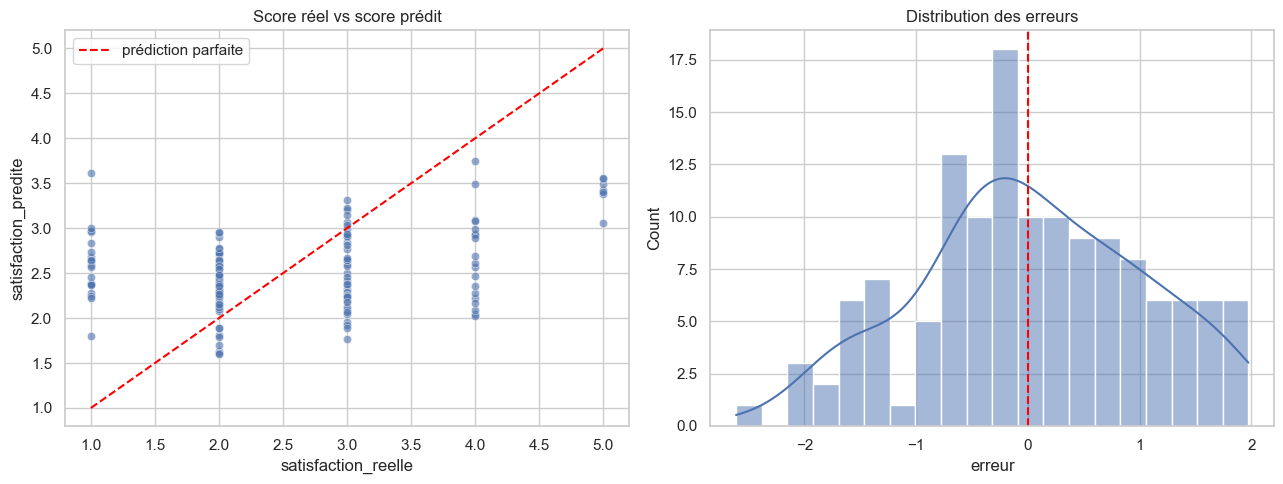

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=evaluation_detaillee,
    x="satisfaction_reelle",
    y="satisfaction_predite",
    alpha=0.6,
    ax=axes[0],
)
axes[0].plot([1, 5], [1, 5], color="red", linestyle="--", label="prédiction parfaite")
axes[0].set_title("Score réel vs score prédit")
axes[0].set_xlim(0.8, 5.2)
axes[0].set_ylim(0.8, 5.2)
axes[0].legend()

sns.histplot(evaluation_detaillee["erreur"], bins=20, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribution des erreurs")

plt.tight_layout()
plt.show()


### 8.3 Conclusion C5

Le modèle est bien entraîné automatiquement et supervisé, avec un protocole robuste : split train/test avant prétraitement, pipeline complet, enrichissement simulé et comparaison à une baseline.

Avec `imprevus`, `reorganisation_necessaire` et `respect_budget`, le diagnostic secondaire s'améliore surtout sur les insatisfaits : rappel indicatif de `0.58` pour `insatisfait_1_2`, `0.51` pour `neutre_3` et seulement `0.12` pour `satisfait_4_5`.

Conclusion : ces variables ajoutent du signal, mais elles sont post-voyage. Cette variante peut donc servir à comprendre les causes de satisfaction ou d'insatisfaction, mais elle ne doit pas être utilisée pour prédire avant le départ.


## 9. Architecture cible industrialisée - synthèse C7

### 9.1 Besoin d'architecture

L'architecture doit permettre de sortir du notebook et de rendre le prototype testable dans un environnement technique cohérent.

Objectifs couverts :

- entraîner le modèle pré-voyage de façon reproductible ;
- exposer une prédiction via une API ;
- proposer une interface simple de test ;
- journaliser les prédictions ;
- surveiller les dérives ;
- valider automatiquement le projet avec la CI/CD ;
- conserver une architecture proportionnée à un prototype.

### 9.2 Contraintes prises en compte

- Performance modèle faible : le système ne doit pas prendre de décision automatique.
- Données synthétiques : la production nécessite une validation sur données réelles.
- Reproductibilité : l'entraînement doit pouvoir être rejoué hors notebook.
- Sobriété : modèle tabulaire simple, pas de NLP lourd en production.
- Portabilité : API conteneurisable avec Docker.
- Gouvernance : validation métier, DSI et juridique requise avant généralisation.

### 9.3 Architecture retenue

Le flux logique retenu est :

`Dataset brut` -> `train.py` -> `artefacts modèle` -> `API FastAPI` -> `Streamlit` -> `logs et monitoring` -> `CI/CD et Docker`.

Cette architecture est adaptée à un **prototype industrialisable**, pas à une production client autonome.

In [16]:
architecture_briques = pd.DataFrame([
    {
        "ordre": 1,
        "brique": "Données",
        "fichiers": "data/Examen_travel_planning_dataset.csv, configs/business_rules.json",
        "role": "source d'entraînement et règles métier centralisées",
        "contrainte_couverte": "traçabilité et cohérence métier",
        "statut": "mis en oeuvre",
    },
    {
        "ordre": 2,
        "brique": "Entraînement",
        "fichiers": "train.py, app/modeling.py",
        "role": "rejouer le nettoyage, le feature engineering et l'entraînement",
        "contrainte_couverte": "reproductibilité hors notebook",
        "statut": "mis en oeuvre",
    },
    {
        "ordre": 3,
        "brique": "Artefacts modèle",
        "fichiers": "models/model_pre_voyage.pkl, models/model_pre_voyage_metadata.json",
        "role": "stocker le pipeline entraîné, les métriques et le profil de référence",
        "contrainte_couverte": "traçabilité des performances",
        "statut": "mis en oeuvre",
    },
    {
        "ordre": 4,
        "brique": "API",
        "fichiers": "app/main.py, app/predictor.py, app/schemas.py",
        "role": "servir /health, /predict et les endpoints de monitoring",
        "contrainte_couverte": "intégration technique et validation des entrées",
        "statut": "mis en oeuvre",
    },
    {
        "ordre": 5,
        "brique": "Interface de test",
        "fichiers": "app_web.py",
        "role": "tester la prédiction sans requête API manuelle",
        "contrainte_couverte": "accessibilité pour le métier",
        "statut": "mis en oeuvre",
    },
    {
        "ordre": 6,
        "brique": "Monitoring",
        "fichiers": "app/monitoring.py, logs/predictions/predictions.jsonl",
        "role": "journaliser les prédictions, suivre les zones d'incertitude et le data drift",
        "contrainte_couverte": "surveillance et revue humaine",
        "statut": "mis en oeuvre",
    },
    {
        "ordre": 7,
        "brique": "CI/CD et conteneurisation",
        "fichiers": ".github/workflows/ci-cd.yml, Dockerfile, docker-compose.yml",
        "role": "tester, contrôler la quality gate et construire l'image Docker si nécessaire",
        "contrainte_couverte": "non-régression et portabilité",
        "statut": "mis en oeuvre sans déploiement serveur automatique",
    },
])

scenarios_architecture = pd.DataFrame([
    {
        "scenario": "Notebook seul",
        "avantage": "simple pour l'analyse",
        "limite": "pas exploitable par une application",
        "decision": "non retenu seul",
    },
    {
        "scenario": "Script + API locale",
        "avantage": "modèle rejouable et prédiction testable",
        "limite": "usage local uniquement",
        "decision": "retenu pour le prototype",
    },
    {
        "scenario": "Docker local",
        "avantage": "environnement portable",
        "limite": "ne suffit pas à une production distante",
        "decision": "retenu pour la portabilité",
    },
    {
        "scenario": "VPS ou cloud managé",
        "avantage": "accès distant et supervision avancée",
        "limite": "coût, sécurité et validation DSI nécessaires",
        "decision": "non retenu à ce stade",
    },
])

acteurs_a_consulter = pd.DataFrame([
    {
        "acteur": "Commanditaire métier",
        "point_a_valider": "usage autorisé du score et seuils d'action humaine",
        "statut": "à consulter avant généralisation",
    },
    {
        "acteur": "DSI",
        "point_a_valider": "hébergement, sécurité, logs, sauvegardes et disponibilité",
        "statut": "à consulter avant déploiement distant",
    },
    {
        "acteur": "DPO / juridique",
        "point_a_valider": "RGPD, AI Act, durée de conservation et information utilisateur",
        "statut": "à consulter avant données réelles",
    },
])

display(architecture_briques)
display(scenarios_architecture)
display(acteurs_a_consulter)

,ordre,brique,fichiers,role,contrainte_couverte,statut
0,1,Données,"data/Examen_travel_planning_dataset.csv, confi...",source d'entraînement et règles métier central...,traçabilité et cohérence métier,mis en oeuvre
1,2,Entraînement,"train.py, app/modeling.py","rejouer le nettoyage, le feature engineering e...",reproductibilité hors notebook,mis en oeuvre
2,3,Artefacts modèle,"models/model_pre_voyage.pkl, models/model_pre_...","stocker le pipeline entraîné, les métriques et...",traçabilité des performances,mis en oeuvre
3,4,API,"app/main.py, app/predictor.py, app/schemas.py","servir /health, /predict et les endpoints de m...",intégration technique et validation des entrées,mis en oeuvre
4,5,Interface de test,app_web.py,tester la prédiction sans requête API manuelle,accessibilité pour le métier,mis en oeuvre
5,6,Monitoring,"app/monitoring.py, logs/predictions/prediction...","journaliser les prédictions, suivre les zones ...",surveillance et revue humaine,mis en oeuvre
6,7,CI/CD et conteneurisation,".github/workflows/ci-cd.yml, Dockerfile, docke...","tester, contrôler la quality gate et construir...",non-régression et portabilité,mis en oeuvre sans déploiement serveur automat...


,scenario,avantage,limite,decision
0,Notebook seul,simple pour l'analyse,pas exploitable par une application,non retenu seul
1,Script + API locale,modèle rejouable et prédiction testable,usage local uniquement,retenu pour le prototype
2,Docker local,environnement portable,ne suffit pas à une production distante,retenu pour la portabilité
3,VPS ou cloud managé,accès distant et supervision avancée,"coût, sécurité et validation DSI nécessaires",non retenu à ce stade


,acteur,point_a_valider,statut
0,Commanditaire métier,usage autorisé du score et seuils d'action hum...,à consulter avant généralisation
1,DSI,"hébergement, sécurité, logs, sauvegardes et di...",à consulter avant déploiement distant
2,DPO / juridique,"RGPD, AI Act, durée de conservation et informa...",à consulter avant données réelles


## 10. API, monitoring et endpoints

Endpoints disponibles :

- `GET /health` : vérifier que l'API fonctionne ;
- `POST /predict` : prédire le score de satisfaction pré-voyage ;
- `GET /monitoring/summary` : résumer les prédictions journalisées ;
- `GET /monitoring/drift` : comparer les nouvelles entrées au profil d'entraînement ;
- `GET /monitoring/alerts` : synthétiser les alertes et proposer une action.

Le monitoring suit les entrées API, les scores prédits, les zones d'incertitude et les dérives. Il ne mesure pas encore la vraie performance en production, car cela nécessiterait des satisfactions réelles collectées après séjour.


In [17]:
if METADATA_PATH.exists():
    metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
    display(pd.DataFrame([metadata["metrics"]]).round(4))
    print(f"Objectif industrialisé : {metadata.get('objective')}")
    print(f"Modèle industrialisé : {metadata.get('model_name')}")
else:
    print("Artefacts modèle absents. Lancer : python train.py")


,mae,rmse,r2,baseline_mae,mae_gain_vs_baseline,test_size,train_rows,test_rows
0,1.0636,1.2522,-0.0001,1.0636,0.0,0.2,1102,276


Objectif industrialisé : pre_voyage_satisfaction_score_regression
Modèle industrialisé : Dummy_mean_regression


## 11. Mesure de performance et impacts - synthèse C8

### 11.1 Objectif de la mesure

La mesure de performance ne sert pas seulement à afficher des scores. Elle doit permettre de décider si la solution peut être utilisée, sous quelles limites et avec quelles actions de suivi.

Dans TravelMind, l'objectif est donc double :

- mesurer si le modèle pré-voyage apporte une vraie valeur par rapport à une baseline ;
- mesurer si son exploitation est acceptable au regard des impacts métier, éthiques et environnementaux.

### 11.2 Indicateurs retenus

- `MAE` : erreur moyenne en points de satisfaction sur l'échelle `1 à 5`.
- `RMSE` : erreur qui pénalise davantage les grosses erreurs.
- `R2` : capacité du modèle à expliquer la satisfaction.
- `gain_mae_vs_baseline` : valeur ajoutée par rapport à une prédiction naïve.
- `zone_incertitude` : indicateur d'exploitation pour imposer une revue humaine si le score est intermédiaire.
- `data drift` : écart entre les données reçues par l'API et le profil d'entraînement.
- `empreinte carbone` : impact environnemental de l'entraînement mesuré avec CodeCarbon lorsque disponible.

In [18]:
# Synthèse C8 : transformer les métriques en décision d'exploitation.
metrics_c8 = training_result.metrics

performance_c8 = pd.DataFrame([
    {
        "indicateur": "MAE",
        "valeur": round(metrics_c8["mae"], 4),
        "lecture": "erreur moyenne d'environ 1 point sur une échelle 1-5",
        "conclusion": "performance faible pour une aide à la décision",
    },
    {
        "indicateur": "RMSE",
        "valeur": round(metrics_c8["rmse"], 4),
        "lecture": "les grosses erreurs restent significatives",
        "conclusion": "prudence nécessaire sur les cas individuels",
    },
    {
        "indicateur": "R2",
        "valeur": round(metrics_c8["r2"], 4),
        "lecture": "variance partiellement expliquée par les variables post-voyage",
        "conclusion": "signal renforcé mais non disponible avant départ",
    },
    {
        "indicateur": "gain MAE vs baseline",
        "valeur": round(metrics_c8["mae_gain_vs_baseline"], 4),
        "lecture": "gain visible, mais lié à des variables post-voyage",
        "conclusion": "modèle non convaincant en performance pure",
    },
])

decision_exploitation = pd.DataFrame([
    {
        "usage": "Démonstrateur technique",
        "decision": "autorisé",
        "raison": "le pipeline, l'API, le monitoring et la CI/CD sont testables",
    },
    {
        "usage": "Support d'analyse interne",
        "decision": "autorisé avec prudence",
        "raison": "le score peut aider à discuter les limites des données",
    },
    {
        "usage": "Aide à la décision commerciale",
        "decision": "non autorisé en l'état",
        "raison": "performance encore insuffisante pour une décision client automatique",
    },
    {
        "usage": "Décision automatique client",
        "decision": "interdit",
        "raison": "risque de surinterprétation et absence de fiabilité suffisante",
    },
])

display(performance_c8)
display(decision_exploitation)

,indicateur,valeur,lecture,conclusion
0,MAE,0.8213,erreur moyenne d'environ 1 point sur une échel...,performance faible pour une aide à la décision
1,RMSE,1.0116,les grosses erreurs restent significatives,prudence nécessaire sur les cas individuels
2,R2,0.1044,variance partiellement expliquée par les varia...,signal renforcé mais non disponible avant départ
3,gain MAE vs baseline,0.0787,"gain visible, mais lié à des variables post-vo...",modèle non convaincant en performance pure


,usage,decision,raison
0,Démonstrateur technique,autorisé,"le pipeline, l'API, le monitoring et la CI/CD ..."
1,Support d'analyse interne,autorisé avec prudence,le score peut aider à discuter les limites des...
2,Aide à la décision commerciale,non autorisé en l'état,performance encore insuffisante pour une décis...
3,Décision automatique client,interdit,risque de surinterprétation et absence de fiab...


In [19]:
# Bilan carbone : lecture de la dernière mesure CodeCarbon si elle existe.
# Si le fichier n'existe pas sur un autre poste, la cellule reste non bloquante.
codecarbon_path = PROJECT_ROOT / "logs" / "codecarbon" / "emissions_notebook_final.csv"

if codecarbon_path.exists():
    emissions_df = pd.read_csv(codecarbon_path)
    derniere_mesure_carbone = emissions_df.tail(1).copy()
    derniere_mesure_carbone["emissions_g_co2e"] = derniere_mesure_carbone["emissions"] * 1000
    colonnes_carbone = [
        "timestamp",
        "duration",
        "emissions",
        "emissions_g_co2e",
        "energy_consumed",
        "cpu_power",
        "ram_power",
        "country_iso_code",
    ]
    display(derniere_mesure_carbone[colonnes_carbone].round(8))
else:
    print("Mesure CodeCarbon absente sur ce poste. Lancer une mesure carbone si besoin.")

,timestamp,duration,emissions,emissions_g_co2e,energy_consumed,cpu_power,ram_power,country_iso_code
6,2026-06-28T02:04:13,1.648254,2.400000e-07,0.000239,0.000004,3.475903,10.0,FRA


### 11.3 Conclusion C8 - décision d'exploitation

Les métriques ne valident pas une mise en production comme outil d'aide à la décision. Elles valident uniquement la faisabilité technique d'un pipeline IA industrialisable.

Conclusion opérationnelle :

- le modèle peut être utilisé pour démontrer l'architecture et le processus MLOps ;
- le score prédit doit rester indicatif ;
- aucune décision automatique ne doit être prise à partir du score ;
- une revue humaine est obligatoire pour tout usage métier ;
- le passage en production exige des données réelles, une nouvelle validation de performance et une revue des biais.

### 11.4 Conclusion impact environnemental

L'impact carbone mesuré est faible car le modèle retenu est un modèle tabulaire simple et le NLP lourd n'est pas industrialisé. Cette sobriété est cohérente avec la faible valeur ajoutée observée : il ne serait pas justifié d'utiliser un modèle beaucoup plus lourd sans gain robuste.

### 11.5 Actions d'amélioration déclenchées

- maintenir le modèle en mode prototype ;
- afficher clairement les limites dans l'API et l'interface ;
- suivre les zones d'incertitude et le data drift ;
- collecter des données réelles pré-voyage plus explicatives ;
- comparer tout nouveau modèle à la baseline avant remplacement ;
- soumettre toute généralisation au métier, à la DSI et au DPO/juridique.

## 12. Éthique, RGPD et AI Act

Points de maîtrise :

- dataset actuel synthétique et anonymisé ;
- exclusion des variables post-voyage pour éviter la fuite de données ;
- supervision humaine obligatoire ;
- interdiction d'usage pour refuser automatiquement un client ou ajuster un prix individuellement ;
- transparence sur les limites et le faible niveau de performance ;
- si données réelles : information client, minimisation, sécurité, durée de conservation et validation DPO.

Positionnement AI Act : TravelMind est un outil d'aide à l'analyse pour une agence de voyages. Il n'est pas identifié comme système à haut risque dans le cadre actuel, mais il nécessite une alphabétisation IA des utilisateurs et une supervision humaine.


## 13. Amélioration continue

La priorité n'est pas d'ajouter des modèles plus complexes, mais d'améliorer les données disponibles avant le départ.

Données à collecter pour une version future :

- attentes explicites du client ;
- préférences détaillées ;
- contraintes personnelles ;
- historique client ;
- canal de réservation ;
- niveau d'accompagnement souhaité ;
- satisfaction réelle observée après séjour.

Le réentraînement devra être réalisé uniquement après validation métier, contrôle qualité et comparaison avec le modèle précédent.


## 14. Synthèse finale rattrapage

TravelMind démontre une démarche IA complète : cadrage, préparation, modélisation, industrialisation, API, interface, monitoring, Docker et CI/CD.

La version rattrapage clarifie la convergence : le modèle industrialisé reste une **régression pré-voyage** qui prédit un score de satisfaction de `1 à 5` sans variables post-voyage.

Le notebook `_700` ajoute un essai séparé avec `imprevus`, `reorganisation_necessaire`, `respect_budget` et un enrichissement simulé. Les scores progressent (`MAE = 0.8213`, `R2 = 0.1044` pour `RidgeRegression_pre`; `MAE = 0.8000`, `R2 = 0.2143` pour `GradientBoostingRegressor_pre`), mais cette progression confirme surtout que le signal utile est en partie post-voyage. Cette variante doit donc rester exploratoire et ne pas être industrialisée pour une prédiction avant départ.
